# Подготовка месячных таблиц для анализа

Анализ и ответы на бизнес вопросы в файле `telecom_analysis.ipynb`.

**При подготовке к анализу необходимо:**
- Познакомиться с данными
- Предобработать данные
- Подгатовить таблицы к анализу
- Сохранить их 

## Импорт библиотек и данных

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from pathlib import Path

In [123]:
calls = pd.read_csv('../data/raw/calls.csv')
internet = pd.read_csv('../data/raw/internet.csv')
messages = pd.read_csv('../data/raw/messages.csv')
tariffs = pd.read_csv('../data/raw/tariffs.csv')
users = pd.read_csv('../data/raw/users.csv')

In [124]:
HEADER = "\033[0;37;40m"
RESET = "\033[0m"

### Описание полей таблиц

**Таблица users**
- `user_id` — уникальный идентификатор пользователя
- `first_name` — имя пользователя
- `last_name` — фамилия пользователя
- `age` — возраст пользователя 
- `reg_date` — дата подключения тарифа (день, месяц, год)
- `churn_date` — дата прекращения пользования тарифом 
- `city` — город проживания пользователя
- `tariff` — название тарифного плана

**Таблица calls**
- `id` — уникальный номер звонка
- `call_date` — дата звонка
- `duration` — длительность звонка в минутах
- `user_id` — идентификатор пользователя, сделавшего звонок

**Таблица messages**
- `id` — уникальный номер сообщения
- `message_date` — дата сообщения
- `user_id` — идентификатор пользователя, отправившего сообщение

**Таблица internet**
- `id` — уникальный номер сессии
- `mb_used` — объём потраченного за сессию интернет-трафика (в мегабайтах)
- `session_date` — дата интернет-сессии
- `user_id` — идентификатор пользователя

**Таблица tariffs**
- `tariff_name` — название тарифа
- `rub_monthly_fee` — ежемесячная абонентская плата в рублях
- `minutes_included` — количество минут разговора в месяц, включённых в абонентскую плату
- `messages_included` — количество сообщений в месяц, включённых в абонентскую плату
- `mb_per_month_included` — объём интернет-трафика, включённого в абонентскую плату (в мегабайтах)
- `rub_per_minute` — стоимость минуты разговора сверх тарифного пакета (например, если в тарифе 100 минут разговора в месяц, то со 101 минуты будет взиматься плата)
- `rub_per_message` — стоимость отправки сообщения сверх тарифного пакета
- `rub_per_gb` — стоимость дополнительного гигабайта интернет-трафика сверх тарифного пакета (1 гигабайт = 1024 мегабайта)

## Знакомство с данными

In [125]:
def get_info(df):
  print(f"Кол-во строк: {len(df)} \nКол-во колонок: {df.shape[1]}\n"
    f"Дубликаты: {df.duplicated().sum()}\n"
    f"Память: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

  display(df.head())
  print('___________')
  
  print(f"{'GENERAL'}")
  profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nunique": df.nunique(dropna=False),
    "na": df.isna().sum(),
    "na%": (df.isna().mean() * 100).round(2),
  })
  display(profile.T)
  
  print('___________')
  num = df.select_dtypes(include="number")
  if not num.empty:
    print(f"DESCRIBE")
    display(num.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

In [126]:
tables = [calls, internet, messages, tariffs, users]
names = ['calls', 'internet', 'messages', 'tariffs', 'users']

for table, name in zip(tables, names):
  print(f'{HEADER} ___Таблица: {name.upper()}___ {RESET}')
  get_info(table)
  print(f'Конец \n')


 ___Таблица: CALLS___ 
Кол-во строк: 202607 
Кол-во колонок: 4
Дубликаты: 0
Память: 26.7 MB


,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


___________
GENERAL


,id,call_date,duration,user_id
dtype,str,str,float64,int64
nunique,202607,365,2871,492
na,0,0,0,0
na%,0.0,0.0,0.0,0.0


___________
DESCRIBE


...

___________
GENERAL


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
dtype,int64,int64,str,str,str,str,str,str
nunique,500,58,34,76,246,419,270,2
na,0,0,462,0,0,0,0,0
na%,0.0,0.0,92.4,0.0,0.0,0.0,0.0,0.0


___________
DESCRIBE


,user_id,age
count,500.00,500.00
mean,1249.50,46.59
std,144.48,16.67
min,1000.00,18.00
1%,1004.99,18.00
5%,1024.95,21.00
25%,1124.75,32.00
50%,1249.50,46.00
75%,1374.25,62.00
95%,1474.05,72.05


Конец 



### Краткий вывод по данным

**Таблица `calls`**
- В таблице 202607 записи, дубликатов и пропусков нет. 
- Все IDs уникальные. 
- Колонка `call_date` имеет тип данных `str` в следующем шаге необходимо преобразовать ее в `datetime`
- `duration` до 5го процентиля равен 0 - это недозвоны

**Таблица `internet`**
- В таблице 149396 записей, дубликатов и пропусков нет. 
- `session_date` имеет тип данных `str` в следующем шаге необходимо преобразовать ее в `datetime`
- Лишняя колонка `unnamed` дублирующая индекс

**Таблица `messages`**
- В таблице 123036 записей, дубликатов и пропусков нет. 
- `message_date` имеет тип данных `str` в следующем шаге необходимо преобразовать ее в `datetime`

**Таблица `tariffs`**
- 2 строки с описанием планов
- Нет недостающих значений, нет дубликатов, все данные соответствуют типу данных

**Таблица `users`**
- В таблице 500 записей, дубликатов нет. 
- `reg_date`, `churn_date` имеют тип данных `str` в следующем шаге необходимо преобразовать ее в `datetime`
- В колонке `churn_date` есть пропущенные значения, свзязанно это с тем, что у пользователя еще действует тариф


## Предобработка данных

In [127]:
# Удалим дублирующую колонку в таблице internet
internet.drop(columns='Unnamed: 0', inplace=True)
internet.head(1)

,id,mb_used,session_date,user_id
0,1000_0,112.95,2018-11-25,1000


In [128]:
## Преобразуем колонки с датой в datetime
to_dt = {
  'call_date': calls,
  'session_date': internet,
  'message_date': messages,
  'reg_date': users,
  'churn_date': users, 
}

for col, table in to_dt.items():
  table[col] = pd.to_datetime(table[col], format='%Y-%m-%d')

  print(f'\n{HEADER}{col}{RESET}')
  print(f'Минимальная дата: {table[col].min()}, Максимальная дата: {table[col].max()}')
  table[[col]].info()


call_date
Минимальная дата: 2018-01-01 00:00:00, Максимальная дата: 2018-12-31 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 1 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   call_date  202607 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 1.5 MB

session_date
Минимальная дата: 2018-01-01 00:00:00, Максимальная дата: 2018-12-31 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 1 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   session_date  149396 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 1.1 MB

message_date
Минимальная дата: 2018-01-02 00:00:00, Максимальная дата: 2018-12-31 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 1 columns):
 #   Column        Non-Null Count   Dty

#### Звонки

Поскольку по правилу оператора каждый звонок округляется до минут (1 секундный звонок будет засчитан как 1 минута), округлим каждое значение до целого числа. 

In [129]:
# Окргулим продолжительность звонка до целого числа
calls['duration'] = np.ceil(calls['duration']).astype(int)
print(f'Доля недозвонов: {len(calls[calls["duration"] == 0]) / len(calls):.1%}')
calls.sample(3)

Доля недозвонов: 19.6%


,id,call_date,duration,user_id
147407,1375_238,2018-02-25,14,1375
117979,1303_247,2018-09-01,0,1303
92702,1233_47,2018-12-30,6,1233


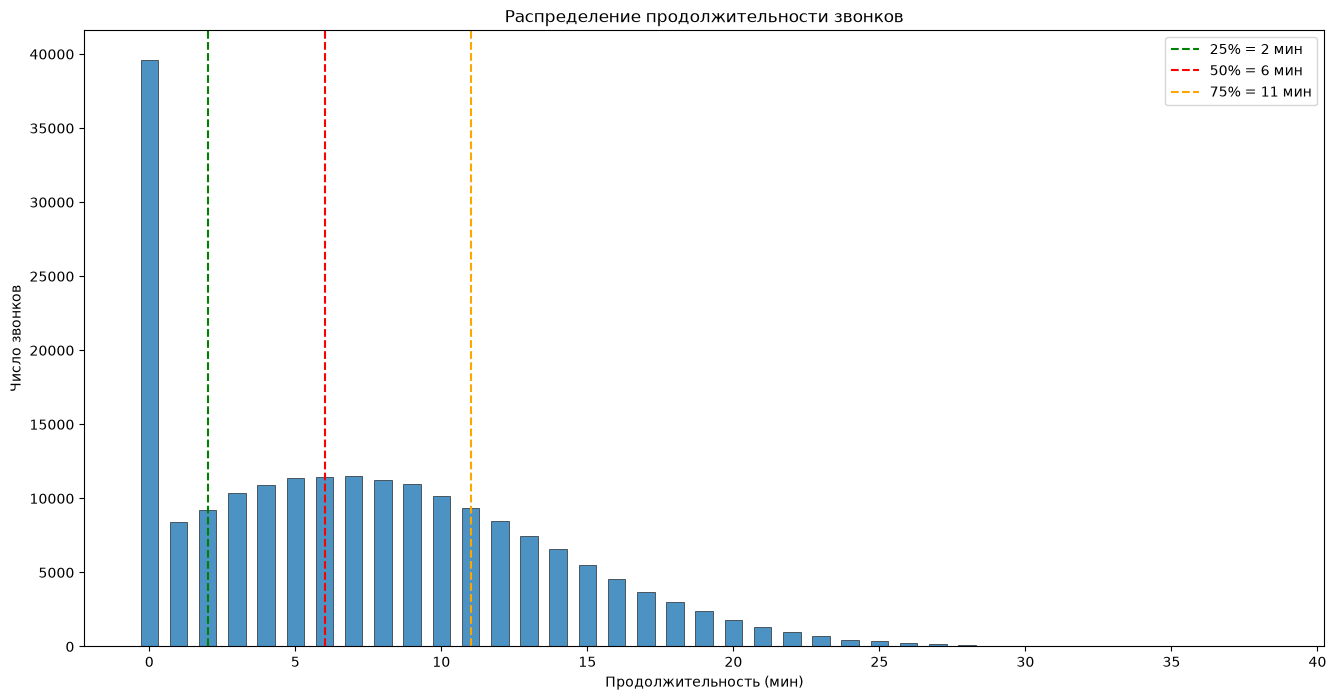

In [130]:
fig, ax = plt.subplots(figsize=(16, 8))
counts = calls['duration'].value_counts().sort_index()
ax.bar(
    counts.index,     
    counts.values,    
    width=0.6,
    color='tab:blue',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
)

q25, q50, q75 = calls['duration'].quantile([0.25, 0.5, 0.75])
ax.axvline(q25, color='green', linestyle='--', label=f'25% = {q25:.0f} мин')
ax.axvline(q50, color='red', linestyle='--', label=f'50% = {q50:.0f} мин')
ax.axvline(q75, color='orange', linestyle='--', label=f'75% = {q75:.0f} мин')

ax.set_title('Распределение продолжительности звонков')
ax.set_xlabel('Продолжительность (мин)')
ax.set_ylabel('Число звонков')
ax.legend()
plt.show()

Пик 0 мин — недозвоны. Половина звонков длится не больше 6 мин (включая недозвоны).

#### Трафик

In [131]:
print(f'Доля сессий без трафика: {len(internet[internet["mb_used"] == 0]) / len(internet):.1%}')

Доля сессий без трафика: 13.1%


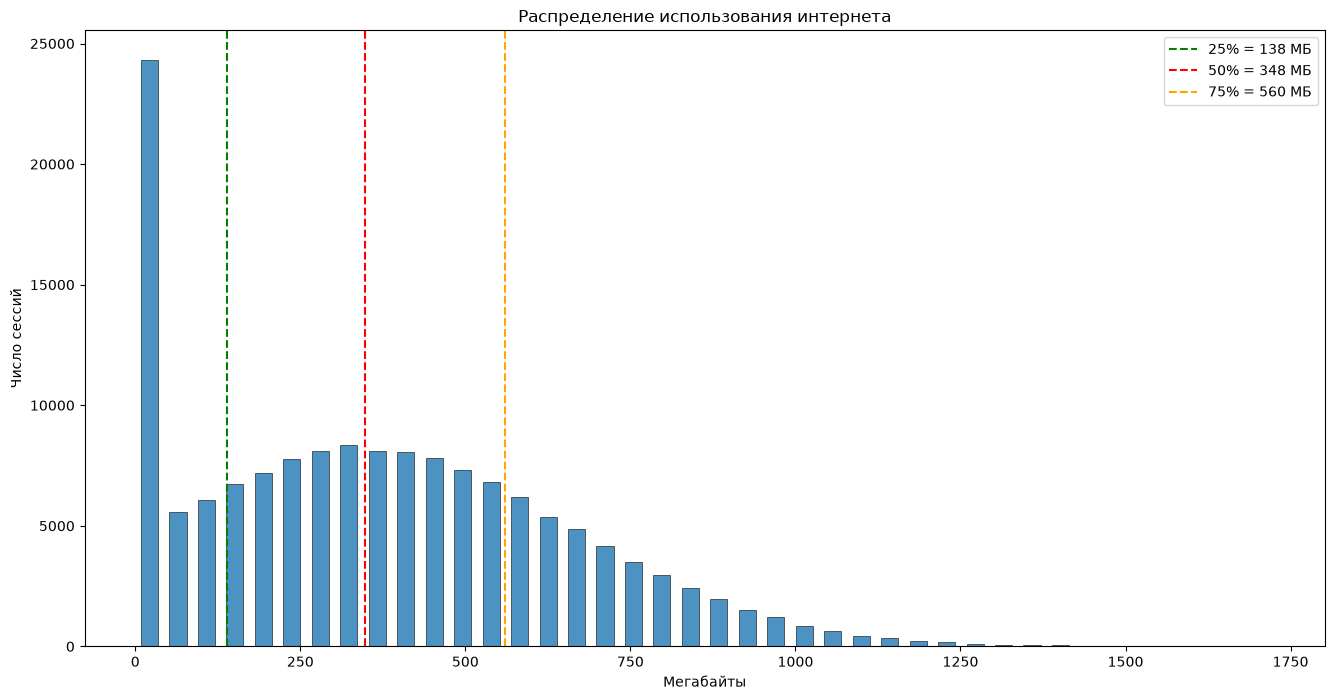

In [132]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.hist(
    internet['mb_used'],
    bins=40,
    rwidth=0.6,
    color='tab:blue',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
)

q25, q50, q75 = internet['mb_used'].quantile([0.25, 0.5, 0.75])
ax.axvline(q25, color='green', linestyle='--', label=f'25% = {q25:.0f} МБ')
ax.axvline(q50, color='red', linestyle='--', label=f'50% = {q50:.0f} МБ')
ax.axvline(q75, color='orange', linestyle='--', label=f'75% = {q75:.0f} МБ')

ax.set_title('Распределение использования интернета')
ax.set_xlabel('Мегабайты')
ax.set_ylabel('Число сессий')
ax.legend()
plt.show()

Пик на 0 МБ - сессии без трафика. Половина сессий — не больше 348 МБ.

#### Тарифы

В таблице `tariffs` переведем МБ в ГБ колонке `mb_per_month_included` 

In [133]:
tariffs['mb_per_month_included'] = np.ceil(tariffs['mb_per_month_included'] / 1024).astype('int')
tariffs = tariffs.rename(columns={'mb_per_month_included': 'gb_per_month_included'})

In [134]:
tariffs.head(2)

,messages_included,gb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15,500,550,200,3,3,smart
1,1000,30,3000,1950,150,1,1,ultra


### Вывод блока
1. Удален колонка `unnamed` которая дублировала индекс в таблице `internet`
2. Колонки `reg_date`, `call_date`, `message_date`, `session_date` и `churn_date` приведены к `datetime`
3. В таблице `calls` колонка `duration` округлена до большего целого. Процент недозвона составляет `19.6%`
4. Доля сессий без трафика составляет `13.1%`
5. В таблице `tariffs` произвел трансормацию МБ в ГБ в столбце `mb_per_month_included` и переименовал колонку в `gb_per_month_included`

## Подготовка аналитических таблиц

Посчитаем по каждому месяцу, сколько пользователь портатил минут, сообщений и трафика

Сначала вычислим номер месяца в таблицах `calls`, `internet`, `messages`

In [144]:
tables = [calls, internet, messages]
columns = ['call_date', 'session_date' , 'message_date']
names = ['calls', 'internet', 'messages']

for table, col, name in zip(tables, columns, names):
  table['month'] = table[col].dt.month
  print(f'Колонки в таблице {name}: {", ".join(table.columns)}')

Колонки в таблице calls: id, call_date, duration, user_id, month
Колонки в таблице internet: id, mb_used, session_date, user_id, month
Колонки в таблице messages: id, message_date, user_id, month


#### Групировка таблицы `calls`

In [136]:
calls_group = calls.groupby(['user_id', 'month']) \
                         .agg(minutes_per_month=('duration', 'sum'), 
                              calls_cnt_per_month=('duration', 'count')) \
                         .reset_index() \
                         .sort_values(['user_id', 'month'])

calls_group.head()

,user_id,month,minutes_per_month,calls_cnt_per_month
0,1000,5,159,22
1,1000,6,172,43
2,1000,7,340,47
3,1000,8,408,52
4,1000,9,466,58


#### Групировка таблицы `internet`

In [137]:
internet_group = internet.groupby(['user_id', 'month']) \
                         .agg(mb_used_per_month=('mb_used', 'sum'),
                              session_cnt_per_month=('mb_used', 'count')) \
                         .reset_index() \
                         .sort_values(['user_id', 'month'])

internet_group['gb_used_per_month'] = np.ceil(internet_group['mb_used_per_month'] / 1024).astype(int)
internet_group = internet_group.drop(columns='mb_used_per_month')
internet_group.head()

,user_id,month,session_cnt_per_month,gb_used_per_month
0,1000,5,5,3
1,1000,6,49,23
2,1000,7,29,14
3,1000,8,29,14
4,1000,9,27,15


#### Групировка таблицы `messages`

In [140]:
messages_group = messages.groupby(['user_id', 'month']) \
                         .agg(used_msg_per_month=('message_date', 'count')) \
                         .reset_index() \
                         .sort_values(['user_id', 'month'])
messages_group.head()

,user_id,month,used_msg_per_month
0,1000,5,22
1,1000,6,60
2,1000,7,75
3,1000,8,81
4,1000,9,57


#### Merge талиц

In [141]:
user_month = calls_group.merge(internet_group, on=['user_id', 'month'], how='outer') \
                        .merge(messages_group, on=['user_id', 'month'], how='outer') \
                        .merge(users, on='user_id', how='left')

usage_cols = [
    'minutes_per_month', 'calls_cnt_per_month',
    'gb_used_per_month', 'session_cnt_per_month',
    'used_msg_per_month',
]
user_month[usage_cols] = user_month[usage_cols].fillna(0)

In [142]:
get_info(user_month)

Кол-во строк: 3214 
Кол-во колонок: 14
Дубликаты: 0
Память: 1.3 MB


,user_id,month,minutes_per_month,calls_cnt_per_month,session_cnt_per_month,gb_used_per_month,used_msg_per_month,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,5,159.0,22.0,5.0,3.0,22.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1000,6,172.0,43.0,49.0,23.0,60.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
2,1000,7,340.0,47.0,29.0,14.0,75.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
3,1000,8,408.0,52.0,29.0,14.0,81.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
4,1000,9,466.0,58.0,27.0,15.0,57.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra


___________
GENERAL


,user_id,month,minutes_per_month,calls_cnt_per_month,session_cnt_per_month,gb_used_per_month,used_msg_per_month,age,churn_date,city,first_name,last_name,reg_date,tariff
dtype,int64,int32,float64,float64,float64,float64,float64,int64,datetime64[us],str,str,str,datetime64[us],str
nunique,498,12,925,184,105,48,180,58,32,76,246,417,269,2
na,0,0,0,0,0,0,0,0,3027,0,0,0,0,0
na%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94.18,0.0,0.0,0.0,0.0,0.0


___________
DESCRIBE


,user_id,month,minutes_per_month,calls_cnt_per_month,session_cnt_per_month,gb_used_per_month,used_msg_per_month,age
count,3214.00,3214.00,3214.00,3214.00,3214.00,3214.0,3214.00,3214.00
mean,1251.59,8.32,451.24,63.04,46.48,17.3,38.28,46.64
std,144.66,2.91,241.91,33.24,18.86,7.4,36.15,16.59
min,1000.00,1.00,0.00,0.00,0.00,0.0,0.00,18.00
1%,1005.00,1.00,0.00,0.00,3.00,1.0,0.00,18.00
5%,1024.65,3.00,72.00,10.00,12.00,5.0,0.00,21.00
25%,1125.00,6.00,282.00,40.00,35.00,13.0,9.00,32.00
50%,1253.00,9.00,443.00,62.00,48.00,17.0,30.00,46.00
75%,1378.75,11.00,589.00,82.00,59.00,21.0,57.00,62.00
95%,1475.00,12.00,862.70,120.00,75.00,30.0,106.00,72.00


### Вывод блока
- Данные `calls`, `internet` и `messages` сгруппированы по `user_id` и `month`. Для каждого пользователя за месяц посчитаны объём услуги и число действий. 
- Трафик в таблице `internet` переведён в гигабайты. 
- Сгрупированные таблицы соединены с таблицей `users`

## Сохранение обработанных данных

In [143]:
out = Path('../data/processed')
out.mkdir(parents=True, exist_ok=True)

tables = {
  'tariffs': tariffs,
  'user_month': user_month
}

for name, table in tables.items():
  path = out / f'{name}.csv'
  try:
    table.to_csv(path, index=False)
    print(f'{path} — сохранено успешно')
  except Exception as e:
    print(f'{path} — ошибка: {e}')

../data/processed/tariffs.csv — сохранено успешно
../data/processed/user_month.csv — сохранено успешно


## Итог
- приведены типы дат
- удалена дублирующая колонка в `internet`
- длительность звонков округлена вверх до минут
- таблицы услуг сгруппированы по пользователю и месяцу
- посчитаны минуты, число звонков, SMS, сессии и трафик в ГБ
- результат сохранён в `data/processed/`